<a href="https://colab.research.google.com/github/shamikkarkhanis/csci4170-paiml/blob/main/hw6_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MDP: FrozenLake

- State Space: A 4x4 grid which means 16 states (0-15). The agent starts at the top left (state 0) and tries to reach the goal at the bottom right (state 15). The grid contains Safe (S), Frozen (F), Hole (H), and Goal (G) tiles.
- Action Space: 4 discrete actions: 0: move left, 1: move down, 2: move right, 3: move up
- Reward Structure: +1 for reaching the goal (G) state. 0 for all other transitions.
- Discount Factor: using gamma = 0.99.

In [ ]:
!pip install gymnasium
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
def value_iteration(env, gamma=0.99, theta=1e-8):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)

    while True:
        delta = 0
        for s in range(n_states):
            v = V[s]
            action_values = np.zeros(n_actions)

            for a in range(n_actions):
                for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_state] * (not done))

            V[s] = np.max(action_values)
            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    # get policy
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        action_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                action_values[a] += prob * (reward + gamma * V[next_state] * (not done))
        policy[s] = np.argmax(action_values)

    return V, policy

def print_policy(policy, shape=(4, 4)):
    action_mapping = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    policy_grid = np.array([action_mapping[a] for a in policy]).reshape(shape)
    print("Policy Grid:")
    for row in policy_grid:
        print(" ".join(row))

def plot_value_function(V, shape=(4, 4)):
    plt.figure(figsize=(6, 5))
    sns.heatmap(V.reshape(shape), annot=True, cmap="coolwarm", cbar=True, fmt=".3f")
    plt.title("Value Function")
    plt.show()

### Value iteration

Results for deterministic FrozenLake with gamma = 0.99
--------------------------------------------------


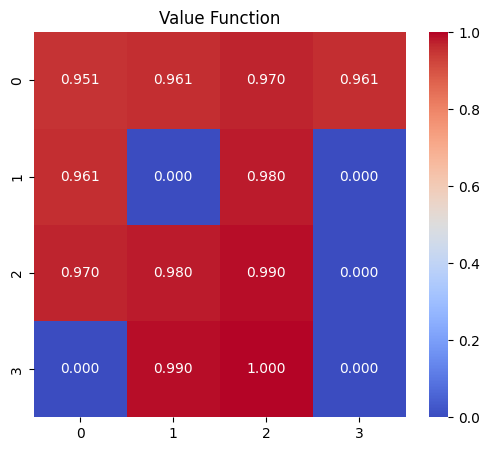



Policy Grid:
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


In [14]:
# Create deterministic FrozenLake
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False)

gamma = 0.99
V_opt, policy_opt = value_iteration(env, gamma=gamma)

print(f"Results for deterministic FrozenLake with gamma = {gamma}")
print("-" * 50)
plot_value_function(V_opt)
print("\n")
print_policy(policy_opt)

### Varying gamma

Results for deterministic FrozenLake with gamma = 0.1


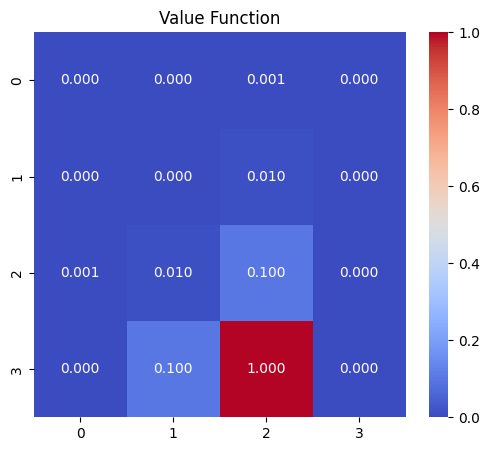

Policy Grid:
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


In [15]:
gamma_low = 0.1
V_low, policy_low = value_iteration(env, gamma=gamma_low)

print(f"Results for deterministic FrozenLake with gamma = {gamma_low}")
plot_value_function(V_low)
print_policy(policy_low)

### Discussion

- Why MDP: This setup is an MDP as it fulfils the requirements of having a set state space, an action space which defines all the movement the agent can make, the Reward function which serves as immediate feedback to the agents action, and a discount factor which determines how much an agent cares about future rewards compared to immediate ones. There is also a transition matrix which is stochastic in our setup. It defines the probabilities where the agent may complete it's indended action.  

- What is the policy doing: with our gamma being 0.99 we have clearly placed an emphases on future rewards rather than short term. This causes the agent to priorize the shortest safe path to the goal. This is why we see many successful squares as the agent is successufll reaching the goal state. In the gamma = 0.1 example we can see the agent is basically blind until it's close to the goal state. there is no successful path.